<!-- [reviewer-header] auto-generated; safe to keep at the top of the notebook -->


## Reviewer notes

**What this notebook does.** Leave-one-sequence-out jackknife (drop each of the 7 memorized sequences and re-run LOO). Quantifies per-sequence contribution.

**Paper section.** Appendix G.2 (sequence jackknife)

**Outputs.** 1 JSON and 1 PNG.

**Hardware / runtime.** any, ~~30 s (uses cache).

**How to run from a fresh GitHub clone.**

1. Click the "Open in Colab" badge above (or upload to Kaggle / run locally).
2. The first code cell installs all dependencies via `pip`.
3. Output paths auto-detect the runtime: Colab Drive (`/content/drive/MyDrive/MIDU/`), Kaggle (`/kaggle/working/`), or a local `./mldu_e_work/` directory. No manual setup is required if you accept the defaults.
4. Mistral-7B notebooks additionally need an `HF_TOKEN` (Colab → Secrets, Kaggle → Add-ons → Secrets, or `os.environ['HF_TOKEN']` locally).

---


# Sequence jackknife — GPT-2 medium

Directly answers: **is the +0.19 gap driven by 1–2 sequences, or by all of them?**

For each sequence k in the 7-sequence pool, drop k entirely (don't include it in training or in the held-out test set), then run LOO on the remaining 6 and report the transformer-layer mean gap and peak gap. If all seven numbers are close to +0.19, the result is robust. If one sequence's removal drops the gap to 0.05, then that sequence is driving the signal.

**Reuses cached activations** from `gpt2m_multiseed.ipynb`. Compute: ~30 sec on T4.

In [1]:
import subprocess, sys
def _pip(p): subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', p], check=False)
try: import transformers
except ImportError: _pip('transformers==4.40.0'); import transformers

In [ ]:
import os, json, time, warnings
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('error', category=ConvergenceWarning)

IS_KAGGLE = Path('/kaggle/working').exists()
IS_COLAB = False
if not IS_KAGGLE:
    try:
        import google.colab  # noqa
        # Only true Colab has /var/colab/hostname; Kaggle preinstalls google.colab too.
        if Path('/var/colab/hostname').exists():
            IS_COLAB = True
    except ImportError:
        pass

if IS_COLAB: BASE = Path('/content')
elif IS_KAGGLE: BASE = Path('/kaggle/working')
else: BASE = Path('.')
ARTIFACT_DIR = BASE / 'artifacts'; ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR   = BASE / 'figures';   FIGURE_DIR.mkdir(parents=True, exist_ok=True)

DRIVE_NAMES = ['MIDU', 'MLDU', 'mldu', 'midu']
PROBE_SEED  = 42
MAX_ITER    = 5000

# Mount Drive FIRST on Colab so the cache can live in MyDrive/MIDU/artifacts/
if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    for n in DRIVE_NAMES:
        d = Path(f'/content/drive/MyDrive/{n}')
        if d.exists():
            ARTIFACT_DIR = d / 'artifacts'; ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
            FIGURE_DIR   = d / 'figures';   FIGURE_DIR.mkdir(parents=True, exist_ok=True)
            print(f'Drive project: {d}  -> outputs at {ARTIFACT_DIR}')
            break
    else:
        print('no MIDU/MLDU folder found in MyDrive; outputs stay in /content/')

# Look for cached activations anywhere they could plausibly be
CACHE_CANDIDATES = [
    ARTIFACT_DIR / 'activations_base.npz',
    Path('./artifacts/activations_base.npz'),
    Path('/content/artifacts/activations_base.npz'),
    Path('/content/activations_base.npz'),
] + [Path(f'/content/drive/MyDrive/{n}/artifacts/activations_base.npz') for n in DRIVE_NAMES] \
  + [Path(f'/content/drive/MyDrive/{n}/activations_base.npz')           for n in DRIVE_NAMES]
cache = next((p for p in CACHE_CANDIDATES if p.exists()), None)

if cache is None:
    print('=' * 70)
    print('activations_base.npz NOT FOUND. Options:')
    print('  1) Run gpt2m_multiseed.ipynb first; it caches the activations.')
    print('  2) Or upload activations_base.npz to /content/ (or MyDrive/MIDU/artifacts/).')
    print('=' * 70)
    raise FileNotFoundError('activations_base.npz missing — see options above')

data = np.load(cache, allow_pickle=True)
VALID_KEYS = sorted({k.split('__')[0] for k in data.files})
reps = {k: {c: data[f'{k}__{c}'] for c in ('mem', 'ctl', 'B')} for k in VALID_KEYS}
NUM_LAYERS = reps[VALID_KEYS[0]]['mem'].shape[1]
CLUSTER_MAP = {'mit_license': 'legal', 'apache_license': 'legal', 'gpl_header': 'legal',
               'bsd_license': 'legal', 'shebang_python': 'code', 'python_main': 'code',
               'wikipedia_python': 'web', 'creative_commons': 'web', 'lorem_ipsum': 'placeholder'}
print(f'loaded {cache}')
print(f'  {len(VALID_KEYS)} sequences, {NUM_LAYERS} depths')
print(f'  keys: {VALID_KEYS}')


In [3]:
def loo(reps, keys, depth, class_pos, class_neg, seed=PROBE_SEED):
    n_ctx = reps[keys[0]][class_pos].shape[0]
    per_seq = {}
    for held_out in keys:
        train_keys = [k for k in keys if k != held_out]
        X_tr, y_tr = [], []
        for k in train_keys:
            X_tr.append(reps[k][class_pos][:, depth, :]); y_tr += [1] * n_ctx
            X_tr.append(reps[k][class_neg][:, depth, :]); y_tr += [0] * n_ctx
        X_tr = np.vstack(X_tr); y_tr = np.array(y_tr)
        X_te = np.vstack([reps[held_out][class_pos][:, depth, :],
                          reps[held_out][class_neg][:, depth, :]])
        y_te = np.array([1] * n_ctx + [0] * n_ctx)
        sc = StandardScaler(); X_tr = sc.fit_transform(X_tr); X_te = sc.transform(X_te)
        clf = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs',
                                 max_iter=MAX_ITER, random_state=seed)
        clf.fit(X_tr, y_tr)
        per_seq[held_out] = float(accuracy_score(y_te, clf.predict(X_te)))
    return np.mean(list(per_seq.values()))

def trans_gap_and_peak(keys):
    true_d = np.array([loo(reps, keys, d, 'mem', 'ctl') for d in range(NUM_LAYERS)])
    pure_d = np.array([loo(reps, keys, d, 'ctl', 'B')   for d in range(NUM_LAYERS)])
    gap_d  = true_d - pure_d
    trans = slice(1, NUM_LAYERS)
    return {
        'trans_gap_mean': float(gap_d[trans].mean()),
        'peak_depth':     int(np.argmax(gap_d[trans])) + 1,
        'peak_gap':       float(gap_d[trans].max()),
        'true_mean':      true_d.tolist(),
        'pure_mean':      pure_d.tolist(),
        'gap_mean':       gap_d.tolist(),
    }

In [4]:
# Baseline — all 7 sequences
t0 = time.time()
baseline = trans_gap_and_peak(VALID_KEYS)
print(f'ALL {len(VALID_KEYS)}: trans_gap={baseline["trans_gap_mean"]:+.4f}   '
      f'peak={baseline["peak_gap"]:+.4f} at L{baseline["peak_depth"]}   '
      f'[{time.time()-t0:.1f}s]')

# Jackknife — drop each sequence in turn
print('\nleave-one-sequence-out:')
jk = {}
for dropped in VALID_KEYS:
    kept = [k for k in VALID_KEYS if k != dropped]
    res = trans_gap_and_peak(kept)
    jk[dropped] = res
    delta_trans = res['trans_gap_mean'] - baseline['trans_gap_mean']
    delta_peak  = res['peak_gap']       - baseline['peak_gap']
    print(f'  drop {dropped:<17} [{CLUSTER_MAP[dropped]:<11}]  '
          f'trans={res["trans_gap_mean"]:+.3f} (Δ{delta_trans:+.3f})  '
          f'peak={res["peak_gap"]:+.3f} at L{res["peak_depth"]:<2} (Δ{delta_peak:+.3f})')

ALL 7: trans_gap=+0.1910   peak=+0.4494 at L21   [9.0s]

leave-one-sequence-out:
  drop apache_license    [legal      ]  trans=+0.227 (Δ+0.036)  peak=+0.524 at L20 (Δ+0.075)
  drop bsd_license       [legal      ]  trans=+0.095 (Δ-0.096)  peak=+0.451 at L21 (Δ+0.002)
  drop creative_commons  [web        ]  trans=+0.185 (Δ-0.006)  peak=+0.566 at L21 (Δ+0.117)
  drop gpl_header        [legal      ]  trans=+0.147 (Δ-0.044)  peak=+0.465 at L21 (Δ+0.016)
  drop lorem_ipsum       [placeholder]  trans=+0.250 (Δ+0.059)  peak=+0.441 at L21 (Δ-0.008)
  drop mit_license       [legal      ]  trans=+0.196 (Δ+0.005)  peak=+0.535 at L20 (Δ+0.085)
  drop python_main       [code       ]  trans=+0.228 (Δ+0.037)  peak=+0.448 at L20 (Δ-0.001)


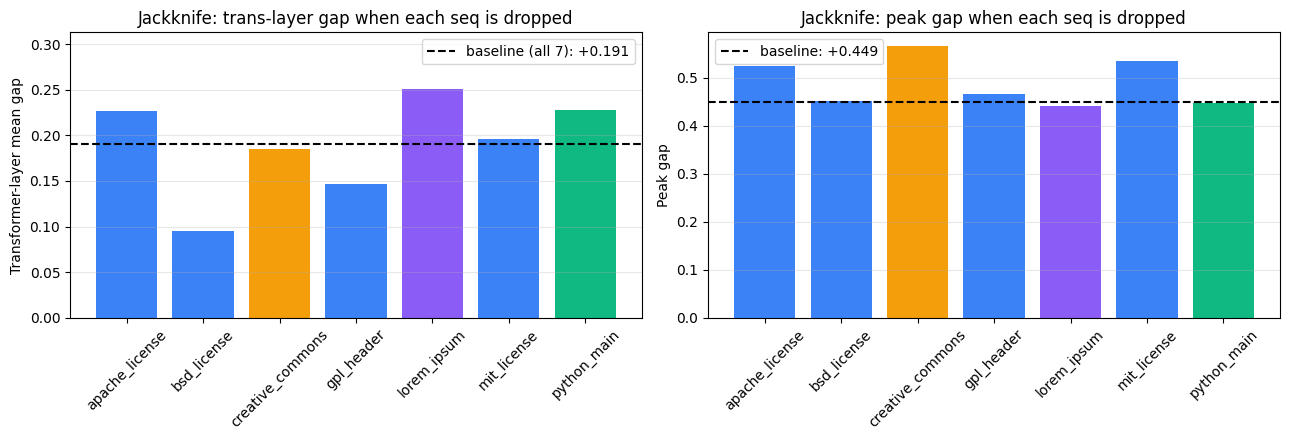


Largest drop:  remove bsd_license  -> gap +0.095  (baseline +0.191, delta -0.096)
Smallest drop: remove lorem_ipsum  -> gap +0.250  (delta +0.059)


In [5]:
# Figure: bar chart of gap per 'drop', with baseline line
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

keys_plot = VALID_KEYS
trans_vals = [jk[k]['trans_gap_mean'] for k in keys_plot]
peak_vals  = [jk[k]['peak_gap']       for k in keys_plot]
colors = ['#3b82f6' if CLUSTER_MAP[k]=='legal' else
          '#10b981' if CLUSTER_MAP[k]=='code'  else
          '#f59e0b' if CLUSTER_MAP[k]=='web'   else '#8b5cf6' for k in keys_plot]

ax = axes[0]
ax.bar(keys_plot, trans_vals, color=colors)
ax.axhline(baseline['trans_gap_mean'], color='k', lw=1.5, ls='--',
           label=f"baseline (all 7): {baseline['trans_gap_mean']:+.3f}")
ax.set_ylabel('Transformer-layer mean gap')
ax.set_title('Jackknife: trans-layer gap when each seq is dropped')
ax.tick_params(axis='x', rotation=45); ax.legend(); ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0.0, max(trans_vals + [baseline['trans_gap_mean']]) * 1.25)

ax = axes[1]
ax.bar(keys_plot, peak_vals, color=colors)
ax.axhline(baseline['peak_gap'], color='k', lw=1.5, ls='--',
           label=f"baseline: {baseline['peak_gap']:+.3f}")
ax.set_ylabel('Peak gap')
ax.set_title('Jackknife: peak gap when each seq is dropped')
ax.tick_params(axis='x', rotation=45); ax.legend(); ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'fig_gpt2m_jackknife.png', dpi=150)
plt.savefig(FIGURE_DIR / 'fig_gpt2m_jackknife.pdf')
plt.show()

# Summary interpretation
trans_arr = np.array(trans_vals)
min_drop  = keys_plot[int(np.argmin(trans_arr))]
max_drop  = keys_plot[int(np.argmax(trans_arr))]
print()
print(f'Largest drop:  remove {min_drop}  -> gap {trans_arr.min():+.3f}  '
      f'(baseline {baseline["trans_gap_mean"]:+.3f}, delta {trans_arr.min() - baseline["trans_gap_mean"]:+.3f})')
print(f'Smallest drop: remove {max_drop}  -> gap {trans_arr.max():+.3f}  '
      f'(delta {trans_arr.max() - baseline["trans_gap_mean"]:+.3f})')

In [6]:
with open(ARTIFACT_DIR / 'loo_jackknife_gpt2m.json', 'w') as f:
    json.dump({'baseline': baseline, 'jackknife': jk,
               'valid_keys': VALID_KEYS,
               'clusters':   [CLUSTER_MAP[k] for k in VALID_KEYS]},
              f, indent=2)
print(f'saved: {ARTIFACT_DIR / "loo_jackknife_gpt2m.json"}')

saved: /content/drive/MyDrive/MIDU/artifacts/loo_jackknife_gpt2m.json
